# 03 · Comparing propulsion architectures *fairly*

Five powertrains, **one mission** (same payload, same design range, same airframe assumptions): conventional kerosene, a SAF drop-in, a hybrid-electric, a hydrogen fuel-cell, and a fuel-cell + battery hybrid. The hard part of this comparison is not running the code — it is deciding what 'fair' means and which metric you rank on.

## What we hold fixed, and what we vary

All five use the same baseline mission and aerodynamics from `examples/common.py` (750 nm, ~4.5 t payload, ATR-like airframe). What changes is the **energy carrier and the conversion chain**. We read PhlyGreen's sized masses directly, and layer on a *transparent, clearly-labelled* well-to-wake (WtW) CO₂ accounting so we can compare climate impact — PhlyGreen's own `welltowake`/`climateimpact` modules are the rigorous path (see notebook 06 and `examples/14`).

In [1]:
# --- environment setup (educational tutorials) ---------------------------------
# These notebooks teach concepts *through* PhlyGreen. They use the real design API where
# it exists and small, clearly-labelled pedagogical proxies where it does not.
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
from PhlyGreen import postprocess as pp

from common import (traditional_config, hybrid_config,
                    hydrogen_config, fuelcell_battery_config)
from _learning_utils import safe_design

# --- ILLUSTRATIVE well-to-wake CO2 factors [g CO2e / MJ of delivered energy] ------
# Teaching values only — real numbers depend heavily on the production pathway.
# The grid figure is the single biggest lever on the electrified architectures: we use a
# current European average of ~200 gCO2/kWh (Ember/EEA put the EU power-sector intensity
# around 200-250 gCO2eq/kWh in 2023-24, falling as renewables grow), i.e. 200/3.6 = 56 gCO2e/MJ.
# A coal-heavy grid (~800 gCO2/kWh -> 222 gCO2e/MJ) or a French/Nordic grid (~50 gCO2/kWh
# -> 14 gCO2e/MJ) would change the ranking completely — try it in the suggested modifications.
WTW = {
    'jetA':    89.0,   # fossil Jet-A, combustion + upstream
    'saf':     20.0,   # sustainable aviation fuel (pathway-dependent!)
    'h2_green': 5.0,   # hydrogen from renewable electrolysis
    'grid':    56.0,   # battery electricity, ~200 gCO2/kWh EU-average grid (= 56 gCO2e/MJ)
}
print('WtW CO2 factors [gCO2e/MJ]:', WTW)
print('grid:', WTW['grid'], 'gCO2e/MJ  = ', round(WTW['grid'] * 3.6), 'gCO2/kWh')

WtW CO2 factors [gCO2e/MJ]: {'jetA': 89.0, 'saf': 20.0, 'h2_green': 5.0, 'grid': 56.0}
grid: 56.0 gCO2e/MJ  =  202 gCO2/kWh


## Size every architecture

A hybrid is only as good as **where** it spends its battery. There are two fundamentally
different reasons to add a battery, and we use the *right* one for each architecture:

- **Energy hybridization (the hybrid-electric).** The battery supplies a large share of the
  *cruise* power for a long time, displacing kerosene with grid electricity. The lever is
  **CO₂**; the cost is a big battery sized for cruise *energy*. Here: 50% of cruise power.
- **Power hybridization (the fuel-cell + battery).** The battery only covers part of the brief,
  high-power **take-off + climb** peak, so the fuel cell can be sized for the much lower
  *cruise* power — a smaller, lighter stack. The battery stays small because it delivers
  *power*, not energy. Cruise runs on hydrogen alone.

> A token battery used the *wrong* way (e.g. a small battery dribbling into cruise) just adds
> dead weight — which is exactly the trap a naïve comparison falls into. Below, each config
> encodes its strategy through the per-segment supplied-power ratio `phi`.

We size each aircraft, then split its onboard energy into a *fuel/H₂* chemical part and a
*battery* electrical part so the WtW CO₂ uses the right factor for each.

In [2]:
def chemical_MJ(mass_kg, lhv_J):
    return (mass_kg or 0.0) * lhv_J / 1e6

def battery_MJ(mass_kg, specific_energy_Wh_kg):
    # battery *capacity* carried, as an energy proxy [MJ]
    return (mass_kg or 0.0) * (specific_energy_Wh_kg or 0.0) * 3600.0 / 1e6

# --- two *deliberate* hybridization strategies (the heart of a fair comparison) ----------
# A hybrid is only as good as *where* it uses its battery. We pick a meaningful strategy for
# each, not a token one.

def hybrid_electric_config():
    # ENERGY hybridization: the battery supplies 50% of the propulsive power throughout cruise,
    # trading kerosene for (cleaner) grid electricity. The pay-off is CO2; the price is a big,
    # heavy battery sized for cruise *energy*.
    cfg = hybrid_config('I')
    for s in cfg.mission_stages.segments:
        if s.segment_type == 'ConstantMachCruise':
            s.phi_start = s.phi_end = 0.5
    return cfg

def fc_battery_config():
    # POWER hybridization: the battery covers part of the short, high-power take-off + climb
    # peak, so the fuel cell only has to be sized for the much lower CRUISE power -- a smaller,
    # lighter stack. Cruise runs on hydrogen alone (phi = 0), so the battery stays small.
    cfg = fuelcell_battery_config(0.0)
    for s in cfg.mission_stages.segments:
        if s.name == 'Takeoff':
            s.phi = 0.2
        elif s.segment_type == 'ConstantRateClimb':
            s.phi_start = s.phi_end = 0.2
        elif s.segment_type == 'ConstantMachCruise':
            s.phi_start = s.phi_end = 0.0
    return cfg

def design_arch(spec):
    cfg = spec['make']()
    res, ok, note = safe_design(cfg)
    row = {'name': spec['name'], 'feasible': ok, 'limit': spec['limit']}
    if not ok:
        row.update(WTO=np.nan, fuel=np.nan, batt=np.nan, energy=np.nan, co2=np.nan)
        return row, None
    # rebuild an aircraft to read the mass breakdown + hydrogen/tank masses
    a = pg.build_aircraft(); a.configure(cfg)
    w = a.weight
    fuel = getattr(w, 'WH2_Fuel', None) or res.Wf        # H2 mass if present, else fuel
    batt = res.WBat or 0.0
    e_fuel = chemical_MJ(fuel, cfg.energy.Ef)
    se = getattr(cfg, 'cell', None).specific_energy if getattr(cfg, 'cell', None) else \
         getattr(cfg.energy, 'battery_specific_energy', 0.0)
    e_batt = battery_MJ(batt, se)
    co2 = (e_fuel * spec['fuel_factor'] + e_batt * WTW['grid']) / 1000.0   # kg CO2e
    row.update(WTO=res.WTO, fuel=fuel, batt=batt, energy=e_fuel + e_batt, co2=co2)
    return row, a

specs = [
    dict(name='Kerosene',   make=traditional_config,    limit='energy density / CO2',            fuel_factor=WTW['jetA']),
    dict(name='SAF',        make=traditional_config,     limit='fuel supply / cost',              fuel_factor=WTW['saf']),
    dict(name='Hybrid',     make=hybrid_electric_config, limit='battery mass (energy hybrid)',    fuel_factor=WTW['jetA']),
    dict(name='H2 fuelcell',make=hydrogen_config,        limit='tank + fuel-cell mass / volume',  fuel_factor=WTW['h2_green']),
    dict(name='FC+battery', make=fc_battery_config,      limit='peak-power battery -> smaller FC', fuel_factor=WTW['h2_green']),
]
rows, acft = [], {}
for s in specs:
    r, a = design_arch(s)
    rows.append(r); acft[s['name']] = a
print('sized', len(rows), 'architectures')

sized 5 architectures


> **SAF is modelled as a drop-in fuel swap** on the *same* airframe as kerosene — same WTO and fuel mass — differing only in its well-to-wake CO₂ factor. That is itself a lesson: SAF changes the *lifecycle emissions*, not the aircraft. Its real limits are feedstock supply and cost, not aircraft design.

## The comparison table

MTOW, fuel/H₂ mass, battery mass, onboard energy, WtW CO₂, feasibility and the main limiting factor — side by side.

In [3]:
hdr = ['architecture','WTO [kg]','fuel/H2 [kg]','battery [kg]','energy [MJ]','WtW CO2 [kg]','feasible','main limit']
print(f"{hdr[0]:13s}{hdr[1]:>10s}{hdr[2]:>13s}{hdr[3]:>13s}{hdr[4]:>12s}{hdr[5]:>13s}  {hdr[6]:<8s} {hdr[7]}")
for r in rows:
    fz = lambda v: '   n/a' if (v is None or (isinstance(v,float) and np.isnan(v))) else f'{v:,.0f}'
    print(f"{r['name']:13s}{fz(r['WTO']):>10s}{fz(r['fuel']):>13s}{fz(r['batt']):>13s}"
          f"{fz(r['energy']):>12s}{fz(r['co2']):>13s}  {str(r['feasible']):<8s} {r['limit']}")

architecture   WTO [kg] fuel/H2 [kg] battery [kg] energy [MJ] WtW CO2 [kg]  feasible main limit
Kerosene         18,327        1,908            0      82,979        7,385  True     energy density / CO2
SAF              18,327        1,908            0      82,979        1,660  True     fuel supply / cost
Hybrid           24,413        1,333        2,970      74,042        6,060  True     battery mass (energy hybrid)
H2 fuelcell      27,745          549            0      65,874          329  True     tank + fuel-cell mass / volume
FC+battery       27,412          533        1,035      64,893          372  True     peak-power battery -> smaller FC


## Mass breakdown by architecture

Where does the take-off weight go? Stacked bars of the PhlyGreen mass groups make the structural cost of each energy carrier obvious — the hydrogen and battery columns carry a large *powertrain/tank* burden the kerosene column does not.

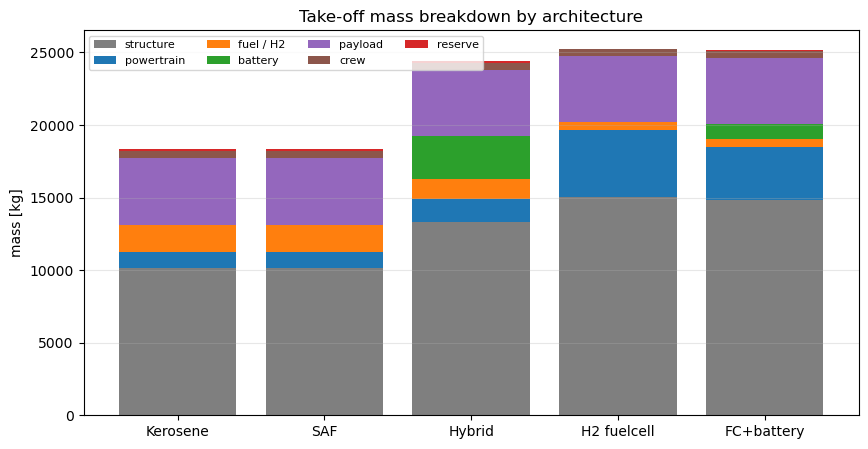

In [4]:
groups = ['structure', 'powertrain', 'fuel / H2', 'battery', 'payload', 'crew', 'reserve']
colors = dict(zip(groups, ['tab:gray','tab:blue','tab:orange','tab:green','tab:purple','tab:brown','tab:red']))
names = [r['name'] for r in rows if r['feasible']]
fig, ax = plt.subplots(figsize=(10, 5))
bottoms = np.zeros(len(names))
for g in groups:
    vals = []
    for nm in names:
        mb = pp.mass_breakdown(acft[nm])
        vals.append(mb.get(g, 0.0))
    vals = np.array(vals)
    ax.bar(names, vals, bottom=bottoms, label=g, color=colors[g])
    bottoms += vals
ax.set_ylabel('mass [kg]'); ax.set_title('Take-off mass breakdown by architecture')
ax.legend(ncol=4, fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.show()

## Energy use and a CO₂ proxy

Two more views: onboard energy (how much energy the mission needs through each chain) and the illustrative well-to-wake CO₂. Note how the *ranking flips* between metrics.

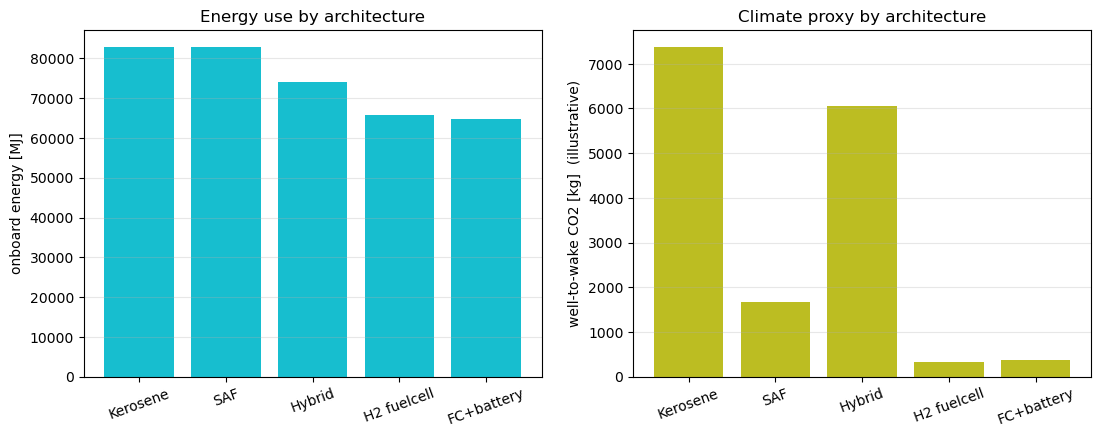

In [5]:
ok = [r for r in rows if r['feasible']]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.bar([r['name'] for r in ok], [r['energy'] for r in ok], color='tab:cyan')
ax1.set_ylabel('onboard energy [MJ]'); ax1.set_title('Energy use by architecture')
ax1.tick_params(axis='x', rotation=20); ax1.grid(axis='y', alpha=0.3)
ax2.bar([r['name'] for r in ok], [r['co2'] for r in ok], color='tab:olive')
ax2.set_ylabel('well-to-wake CO2 [kg]  (illustrative)'); ax2.set_title('Climate proxy by architecture')
ax2.tick_params(axis='x', rotation=20); ax2.grid(axis='y', alpha=0.3)
plt.show()

Read these critically:

- The **hybrid-electric** now cuts WtW CO₂ by a meaningful margin versus kerosene — but *only
  because the grid is relatively clean* (56 gCO₂e/MJ < 89 for Jet-A) — and it pays for that
  with a large jump in take-off weight (the cruise battery is heavy). That is the real
  trade-off: **CO₂ down, mass up.** On a coal-heavy grid the CO₂ saving would vanish or reverse.
- The **fuel-cell + battery** uses *power* hybridization: its small take-off/climb battery lets
  the fuel cell be sized for cruise, so its stack is lighter and its take-off weight is close to
  (or below) the pure-hydrogen aircraft — a genuinely useful hybrid, not dead weight.
- The H₂ and electrified aircraft show **low WtW CO₂ only if the hydrogen is green and the grid
  is clean** — assumptions baked into the `WTW` dict. Change those numbers and the whole ranking
  moves.

## Key takeaways

1. A 'fair' comparison means **same mission, same airframe assumptions** — and being explicit about every efficiency and emission factor.
2. The **ranking depends on the metric**: lightest, least energy, and least CO₂ are often *different* aircraft.
3. The most influential inputs are frequently *off-aircraft* assumptions (where the hydrogen/electricity comes from), not the aircraft model itself.

## Questions for students

1. What does **'fair comparison'** mean here? List three things you had to hold fixed and one you could not.
2. Which assumption most influences the CO₂ ranking — change the `WTW` factors to find out.
3. Why can an architecture look good on CO₂ but poor on mass (or vice versa)? Which would a regulator care about, and which an airline?

## Suggested modifications

- **Decarbonise / dirty the grid.** Set `WTW['grid'] = 14` (a French/Nordic grid, ~50 gCO₂/kWh)
  or `WTW['grid'] = 222` (a coal-heavy grid, ~800 gCO₂/kWh) and re-rank — the hybrid can flip
  from best to worst.
- Set `WTW['h2_green'] = 90` (grey hydrogen from natural gas) and watch the H₂ aircraft lose
  their climate advantage.
- **Change the hybrid strategy.** In `hybrid_electric_config`, raise the cruise `phi` to 0.7 (more
  CO₂ saving, heavier) or also hybridize climb — watch CO₂ and mass move in opposite directions.
- **Change the FC+battery split.** In `fc_battery_config`, sweep the take-off/climb `phi`
  (0.1 → 0.4): there is a sweet spot where the fuel cell shrinks fastest before battery mass
  takes over.
- Swap `hydrogen_config()` for `hydrogen_config(tank=True)` (needs CoolProp) to size a real LH₂ tank.
- Add a 'SAF blend' row at 50% (interpolate the fuel factor between `jetA` and `saf`).

---
*These tutorials are educational. Where the full PhlyGreen capability is not exposed (formal constraint feasibility, non-CO₂ climate weighting) the notebook uses a simplified, clearly-labelled proxy — read the comments before trusting any number.*